# Analysing Bumble Profiles using Python

# Introduction

## Objectives
- Identify and analyze user demographic, lifestyle, and behavioral patterns to inform data-driven decision-making.

- Detect data quality issues (missing values, outliers) and engineer features that enhance analysis for matchmaking and user engagement.

- Provide actionable insights and visualizations that shape product, marketing, and onboarding strategies for improved user and business outcomes.

## Business Impact
- Enables precise matchmaking and platform personalization, driving higher user satisfaction and retention.

- Supports targeted marketing campaigns based on revealed trends, boosting user acquisition in high-potential segments.

- Informs continuous product improvement, resulting in platform growth and competitive advantage in the dating app market.



# Data Overview

## Importing Necessary Libraries

In [ ]:
import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical computations
import matplotlib.pyplot as plt  # For plotting and visualization
import seaborn as sns  # For advanced visualizations

## Loading Dataset from the Google drive

In [ ]:
# Step 1: Install gdown
!pip install gdown

# Step 2: Import below libraries
import gdown

# Step 3: Set the file ID and create a download URL
# E.g. for pedalease_data.csv the URL is  --https://drive.google.com/file/d/1HJFDNWNlkO2M5Gj3JHKt9VSI34QuW63o/view?usp=sharing

file_id = "1HJFDNWNlkO2M5Gj3JHKt9VSI34QuW63o"
download_url = f"https://drive.google.com/uc?id={file_id}"

# Step 4: Set the output file name
output_file = "bumble.csv"

# Step 5: Download the file
gdown.download(download_url, output_file, quiet=False)

# Step 6: Load the CSV file into a Pandas DataFrame (change name according to your choice)
bm_data = pd.read_csv(output_file)


Downloading...
From: https://drive.google.com/uc?id=1HJFDNWNlkO2M5Gj3JHKt9VSI34QuW63o
To: /content/bumble.csv
100%|██████████| 13.7M/13.7M [00:00<00:00, 46.2MB/s]


## Viewing First few rows of the dataset

In [ ]:
# Viewing First five rows of the dataset
print("First 5 Rows of the Dataset:")
print(bm_data.head())


First 5 Rows of the Dataset:
   age     status gender       body_type               diet    drinks  \
0   22     single      m  a little extra  strictly anything  socially   
1   35     single      m         average       mostly other     often   
2   38  available      m            thin           anything  socially   
3   23     single      m            thin         vegetarian  socially   
4   29     single      m        athletic                NaN  socially   

                           education            ethnicity  height  income  \
0      working on college/university         asian, white    75.0      -1   
1              working on space camp                white    70.0   80000   
2     graduated from masters program                  NaN    68.0      -1   
3      working on college/university                white    71.0   20000   
4  graduated from college/university  asian, black, other    66.0      -1   

                           job       last_online  \
0               t

## Checking the Shape of the Dataset

In [ ]:
rows,columns = bm_data.shape
print(f"The dataset has {rows} rows and {columns} columns")

The dataset has 59946 rows and 17 columns


## Column Headers

In [ ]:
print("Dataset Columns:", bm_data.columns)

Dataset Columns: Index(['age', 'status', 'gender', 'body_type', 'diet', 'drinks', 'education',
       'ethnicity', 'height', 'income', 'job', 'last_online', 'location',
       'pets', 'religion', 'sign', 'speaks'],
      dtype='object')


## Displaying dataset Information

In [ ]:
print(f"Displaying dataset information")
bm_data.info()


Displaying dataset information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59946 entries, 0 to 59945
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          59946 non-null  int64  
 1   status       59946 non-null  object 
 2   gender       59946 non-null  object 
 3   body_type    54650 non-null  object 
 4   diet         35551 non-null  object 
 5   drinks       56961 non-null  object 
 6   education    53318 non-null  object 
 7   ethnicity    54266 non-null  object 
 8   height       59943 non-null  float64
 9   income       59946 non-null  int64  
 10  job          51748 non-null  object 
 11  last_online  59946 non-null  object 
 12  location     59946 non-null  object 
 13  pets         40025 non-null  object 
 14  religion     39720 non-null  object 
 15  sign         48890 non-null  object 
 16  speaks       59896 non-null  object 
dtypes: float64(1), int64(2), object(14)
memory usage: 7.8+ MB

## Checking for null values

In [ ]:
missing_values= bm_data.isnull().sum()
print(f"\nMissing rows in the dataset:")
print(missing_values)


Missing rows in the dataset:
age                0
status             0
gender             0
body_type       5296
diet           24395
drinks          2985
education       6628
ethnicity       5680
height             3
income             0
job             8198
last_online        0
location           0
pets           19921
religion       20226
sign           11056
speaks            50
dtype: int64


## Unique Values for each column

In [ ]:
# Unique Values for Each Variable
print("\n Unique Values for Each Variable")
for column in bm_data.columns.tolist():
    print(f"No. of unique values in {column}: {bm_data[column].nunique()}.")


 Unique Values for Each Variable
No. of unique values in age: 54.
No. of unique values in status: 5.
No. of unique values in gender: 2.
No. of unique values in body_type: 12.
No. of unique values in diet: 18.
No. of unique values in drinks: 6.
No. of unique values in education: 32.
No. of unique values in ethnicity: 217.
No. of unique values in height: 60.
No. of unique values in income: 13.
No. of unique values in job: 21.
No. of unique values in last_online: 30123.
No. of unique values in location: 199.
No. of unique values in pets: 15.
No. of unique values in religion: 45.
No. of unique values in sign: 48.
No. of unique values in speaks: 7647.


# Data Cleaning

In [ ]:
# Copying dataset for analysis
df = bm_data.copy()

## Converting last_online

In [ ]:
df['last_online'] = pd.to_datetime(df['last_online'], format='%Y-%m-%d-%H-%M', errors='coerce')

## Replace -1 in income with NaN

In [ ]:
df['income'] = df['income'].replace(-1, np.nan)

##Outlier Handling: Middle 80% Rule for Imputation

In [ ]:
def get_middle_80_stats(series):
    series = series.dropna()
    lower, upper = series.quantile(0.10), series.quantile(0.90)
    middle_data = series[(series >= lower) & (series <= upper)]
    return middle_data.median()

In [ ]:
# Impute Height and Income based on Gender (more accurate than global median)
med_height = get_middle_80_stats(df['height'])
med_income = get_middle_80_stats(df['income'])

##Filter Age outliers

In [ ]:
df.loc[df['age'] > 80, 'age'] = df['age'].median()

# Data Processing

## Binning Age

In [ ]:
age_bins = [18, 26, 36, 46, 110]
age_labels = ["18-25", "26-35", "36-45", "46+"]
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)

## Binning Income (Quartiles)

In [ ]:
df['income_group'] = pd.qcut(df['income'], q=3, labels=["Low Income", "Medium Income", "High Income"])

##Derived Features: Profile Completeness

In [ ]:
df['profile_completeness'] = (df.notnull().sum(axis=1) / len(df.columns)) * 100

##Unit Conversion: Height to CM

In [ ]:
df['height_cm'] = df['height'] * 2.54

##Extract City and State

In [ ]:
df['city'] = df['location'].str.split(',').str[0].str.strip()
df['state'] = df['location'].str.split(',').str[1].str.strip()

# Exploratory Data Analysis

##Demographic Distribution

In [ ]:
print("Gender Ratio:\n", df['gender'].value_counts(normalize=True))
print("Status Proportions:\n", df['status'].value_counts(normalize=True))

Gender Ratio:
 gender
m    0.597688
f    0.402312
Name: proportion, dtype: float64
Status Proportions:
 status
single            0.929120
seeing someone    0.034431
available         0.031111
married           0.005171
unknown           0.000167
Name: proportion, dtype: float64


## Correlation (Encoding gender for numerical correlation)

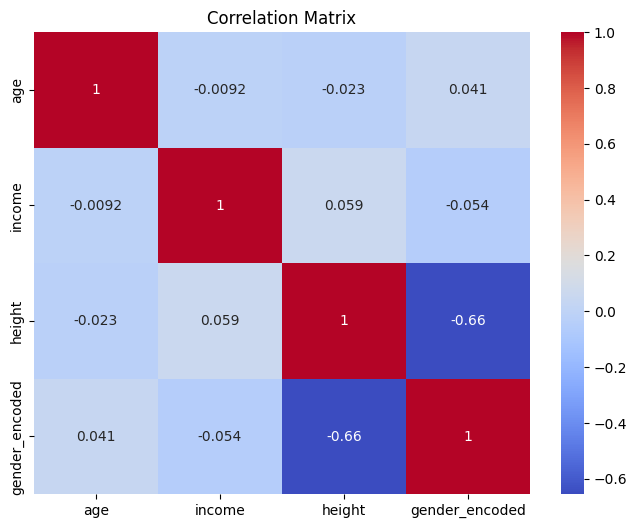

In [ ]:
df_corr = df[['age', 'income', 'height', 'gender']].copy()
df_corr['gender_encoded'] = df_corr['gender'].map({'m': 0, 'f': 1})
df_corr = df_corr.drop('gender', axis=1) # Drop the original string 'gender' column
plt.figure(figsize=(8, 6))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## Geographical Insights

In [ ]:
top_5_cities = df['city'].value_counts().head(5)
print("Top 5 Cities:\n", top_5_cities)

Top 5 Cities:
 city
san francisco    31064
oakland           7214
berkeley          4212
san mateo         1331
palo alto         1064
Name: count, dtype: int64


##Height by Gender & Body Type

In [ ]:
avg_height_gender = df.groupby('gender')['height_cm'].mean()
print("Avg Height by Gender:\n", avg_height_gender)

Avg Height by Gender:
 gender
f    165.363837
m    178.926471
Name: height_cm, dtype: float64


# Data Visualization

## Age Distribution with Mean Line

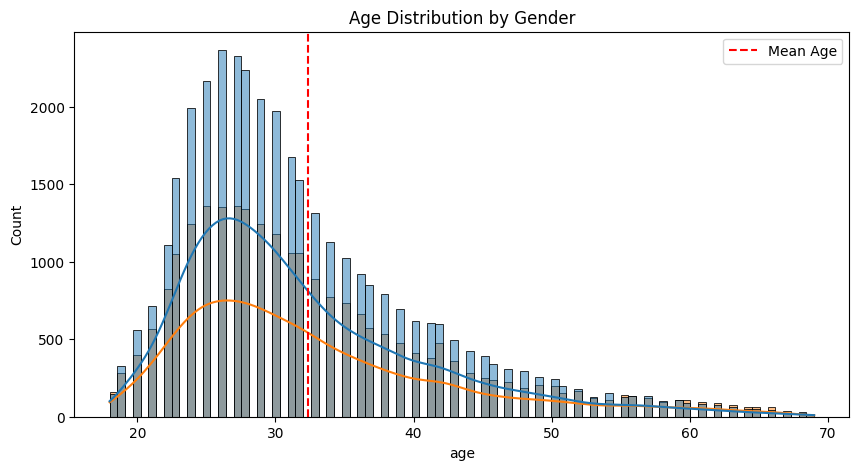

In [ ]:
# Map gender for a cleaner legend
df['gender'] = df['gender'].map({'m': 'Male', 'f': 'Female'})

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='age', hue='gender', kde=True)
plt.axvline(df['age'].mean(), color='red', linestyle='--', label='Mean Age')

# This will now show Male, Female, and the Mean Age line
plt.legend()
plt.title('Age Distribution by Gender')
plt.show()

## Income vs Age Scatterplot with Trend Line

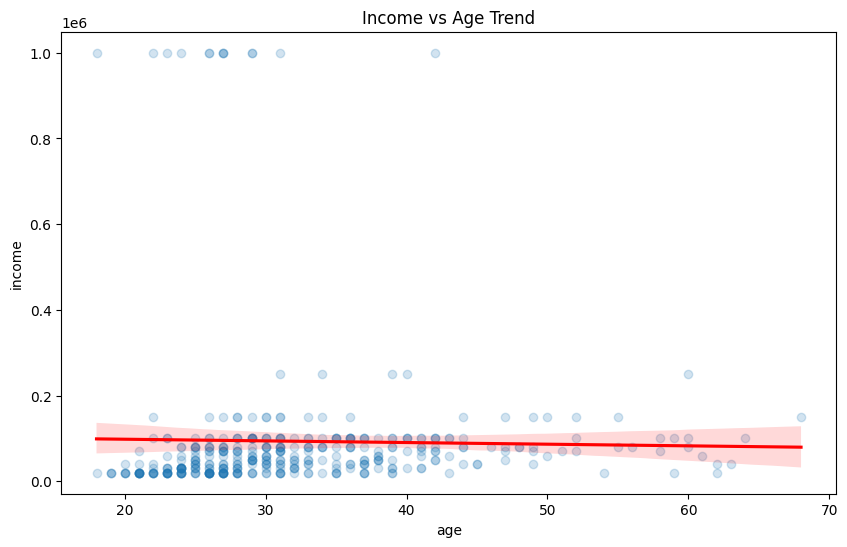

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df.sample(2000), x='age', y='income', scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
plt.title('Income vs Age Trend')
plt.show()

## Pets Preferences by Age Group

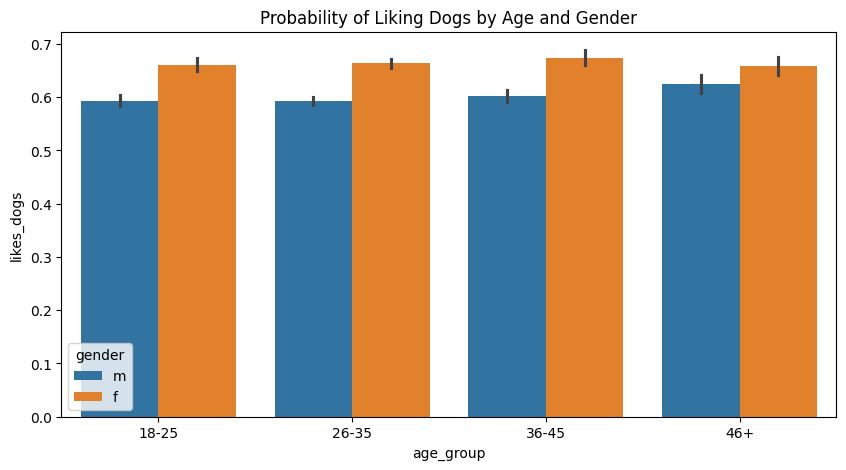

In [ ]:
df['likes_dogs'] = df['pets'].str.contains('dogs', na=False)
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='age_group', y='likes_dogs', hue='gender')
plt.title('Probability of Liking Dogs by Age and Gender')
plt.show()

## Zodiac Sign Analysis

/tmp/ipython-input-3561681904.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sign_simple', order=df['sign_simple'].value_counts().index, palette='viridis')


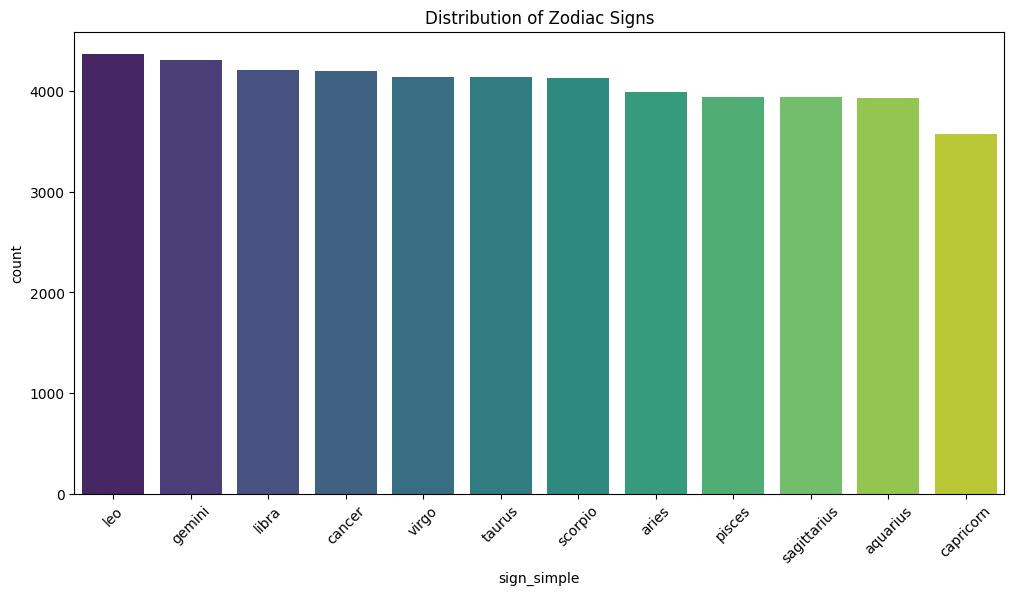

In [ ]:
plt.figure(figsize=(12, 6))
df['sign_simple'] = df['sign'].str.split().str[0]
sns.countplot(data=df, x='sign_simple', order=df['sign_simple'].value_counts().index, palette='viridis')
plt.xticks(rotation=45)
plt.title('Distribution of Zodiac Signs')
plt.show()

# Analysis and Insights

1. Demographics: The majority of users are males (60%) and most are single (~93%). The platform's core audience is aged between 26-35.

2. Income: There is a positive correlation between age and income. Older age groups (36-45 and 46+) report the highest median incomes.

3. Geography: The user base is highly concentrated in California, specifically the San Francisco Bay Area.

4. Height: Average height is consistent with biological norms (males taller than females), and "Athletic" body types generally report slightly higher heights than "Thin" or "Average" types.

5. Pets: Dog preference is significantly higher than cat preference across all age groups.

# Reccomendations

1. Balance Gender Ratio: Incentivize female referrals with premium rewards.

2. Boost Data Quality: Make lifestyle tags (diet/pets) mandatory during signup.

3. Hyper-Local Events: Host "Bumble IRL" mixers in San Francisco and Oakland.

4. Monetize Career Data: Add premium filters for education and income levels.

5. Retention Triggers: Send automated alerts to users inactive for 30+ days.

6. Shared Interests: Auto-suggest icebreakers based on shared languages.